# House Prices - Exploratory Data Analysis

EDA for the Kaggle *House Prices - Advanced Regression Techniques* competition.

**Goal:** understand the target (`SalePrice`), missingness, and which features matter, to guide the feature engineering in `src/features.py`.

**Metric reminder:** the competition is scored on RMSLE, so we care about the *log* of `SalePrice`. Plots and modeling target `log1p(SalePrice)`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Resolve project paths relative to this notebook (notebooks/ -> project root).
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = PROJECT_ROOT / "data" / "raw"
FIG = PROJECT_ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

def savefig(name):
    """Save the current figure to reports/figures."""
    plt.tight_layout()
    plt.savefig(FIG / name, bbox_inches="tight")
    print("saved", FIG / name)

## 1. Load data and inspect shape / dtypes

In [2]:
train = pd.read_csv(RAW / "train.csv")
test = pd.read_csv(RAW / "test.csv")

print("train:", train.shape)
print("test: ", test.shape)
print("\ntest has all train columns except SalePrice:",
      set(train.columns) - set(test.columns))
train.head()

train: (1460, 81)
test:  (1459, 80)

test has all train columns except SalePrice: {'SalePrice'}


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Column dtypes overview
dtype_counts = train.dtypes.value_counts()
print(dtype_counts)
train.info()

str        43
int64      35
float64     3
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    


**Observations**
- Train is **1460 × 81** (79 features + `Id` + `SalePrice`); test is **1459 × 80** (no target).
- The only column difference between train and test is `SalePrice`, as expected.
- Roughly 38 numeric and 43 object columns — but several numeric columns (`MSSubClass`, `MoSold`, `YrSold`) are really *categorical codes*; `src/features.py` already coerces these to strings.

## 2. Target: SalePrice distribution and log1p transform

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

skewness        : 1.883
skew log1p      : 0.121


saved /Users/mlstudio/Claude-Code/Kaggle/HousePrice-v2/reports/figures/saleprice_distribution.png


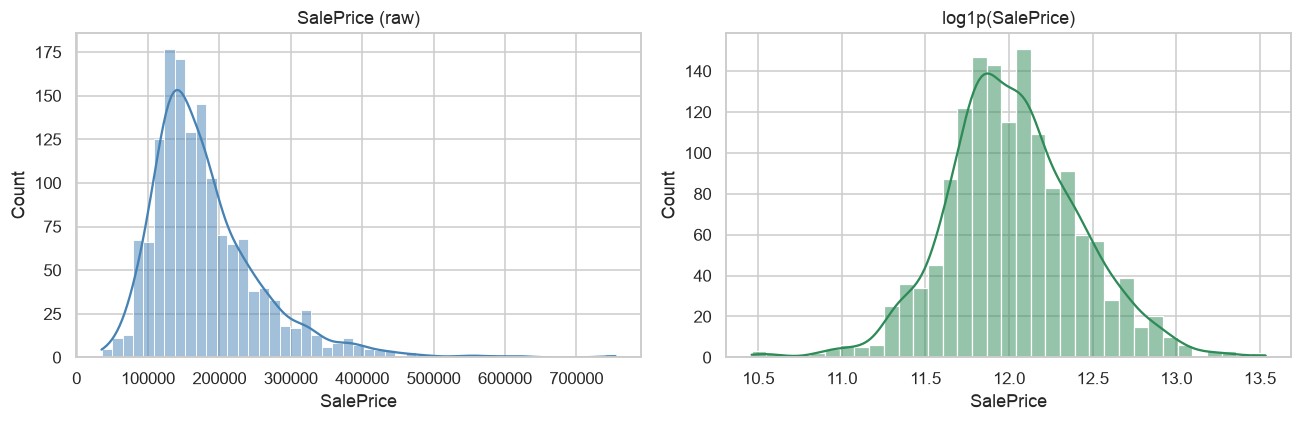

In [4]:
print(train["SalePrice"].describe())
print("\nskewness        :", round(train["SalePrice"].skew(), 3))
print("skew log1p      :", round(np.log1p(train["SalePrice"]).skew(), 3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train["SalePrice"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("SalePrice (raw)")
sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("log1p(SalePrice)")
savefig("saleprice_distribution.png")
plt.show()

**Observations**
- Raw `SalePrice` is strongly **right-skewed** (skew ≈ 1.88) with a long luxury-home tail.
- `log1p(SalePrice)` is almost symmetric (skew ≈ 0.12) and roughly normal. This is why the pipeline trains in log space — it stabilizes variance and makes RMSE in log space equal the competition RMSLE.

## 3. Missing values (count and percentage)

In [5]:
def missing_summary(df):
    count = df.isna().sum()
    pct = (count / len(df) * 100).round(2)
    out = pd.DataFrame({"missing": count, "pct": pct})
    return out[out["missing"] > 0].sort_values("pct", ascending=False)

miss = missing_summary(train)
print(f"{len(miss)} columns with missing values in train\n")
miss

19 columns with missing values in train



,missing,pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


saved /Users/mlstudio/Claude-Code/Kaggle/HousePrice-v2/reports/figures/missing_values.png


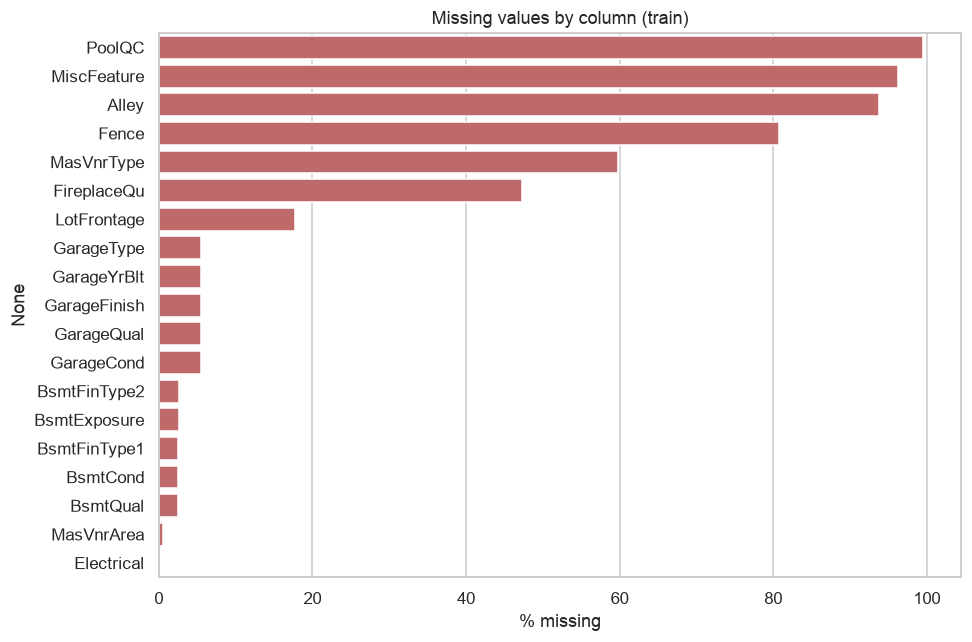

In [6]:
plt.figure(figsize=(9, 6))
sns.barplot(x=miss["pct"], y=miss.index, color="indianred")
plt.xlabel("% missing")
plt.title("Missing values by column (train)")
savefig("missing_values.png")
plt.show()

**Observations**
- The biggest gaps — `PoolQC` (99.5%), `MiscFeature` (96.3%), `Alley` (93.8%), `Fence` (80.8%), `FireplaceQu` (47.3%) — are **"NA = feature absent"**, not random missingness. `src/features.py` fills these with the literal `"None"`.
- The garage block (`GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `GarageYrBlt`) is all missing at the same ~5.5% — these are the homes with no garage.
- `LotFrontage` (17.7%) is genuinely unknown and is better handled by **median imputation** (the preprocessor's default).

## 4. Separate numerical and categorical columns

In [7]:
drop_cols = ["Id", "SalePrice"]
numeric_cols = [c for c in train.select_dtypes("number").columns if c not in drop_cols]
categorical_cols = [c for c in train.select_dtypes("object").columns]

print(f"{len(numeric_cols)} numeric features")
print(f"{len(categorical_cols)} categorical features")
print("\nNumeric :", numeric_cols)
print("\nCategorical:", categorical_cols)

36 numeric features
43 categorical features

Numeric : ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Categorical: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 

/var/folders/hf/0h4pd6zx1vv0dwjx8bgs9r_c0000gp/T/ipykernel_60386/1154263752.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = [c for c in train.select_dtypes("object").columns]


## 5. Top correlations with SalePrice

/var/folders/hf/0h4pd6zx1vv0dwjx8bgs9r_c0000gp/T/ipykernel_60386/2198585262.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette="viridis")


saved /Users/mlstudio/Claude-Code/Kaggle/HousePrice-v2/reports/figures/top_correlations.png


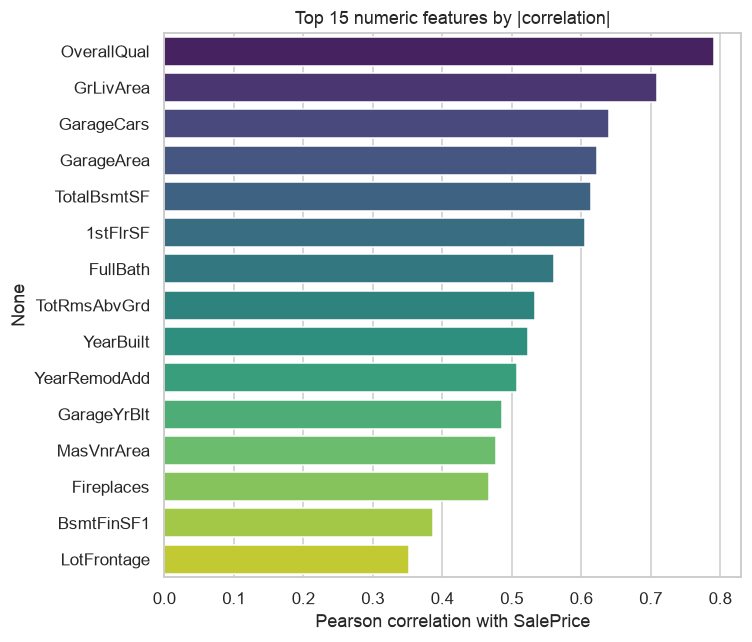

OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
GarageYrBlt     0.486
MasVnrArea      0.477
Fireplaces      0.467
BsmtFinSF1      0.386
LotFrontage     0.352
Name: SalePrice, dtype: float64

In [8]:
corr = train[numeric_cols + ["SalePrice"]].corr()["SalePrice"].drop("SalePrice")
top = corr.abs().sort_values(ascending=False).head(15).index
top_corr = corr[top].sort_values(ascending=False)

plt.figure(figsize=(7, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette="viridis")
plt.xlabel("Pearson correlation with SalePrice")
plt.title("Top 15 numeric features by |correlation|")
savefig("top_correlations.png")
plt.show()
top_corr.round(3)

saved /Users/mlstudio/Claude-Code/Kaggle/HousePrice-v2/reports/figures/correlation_heatmap.png


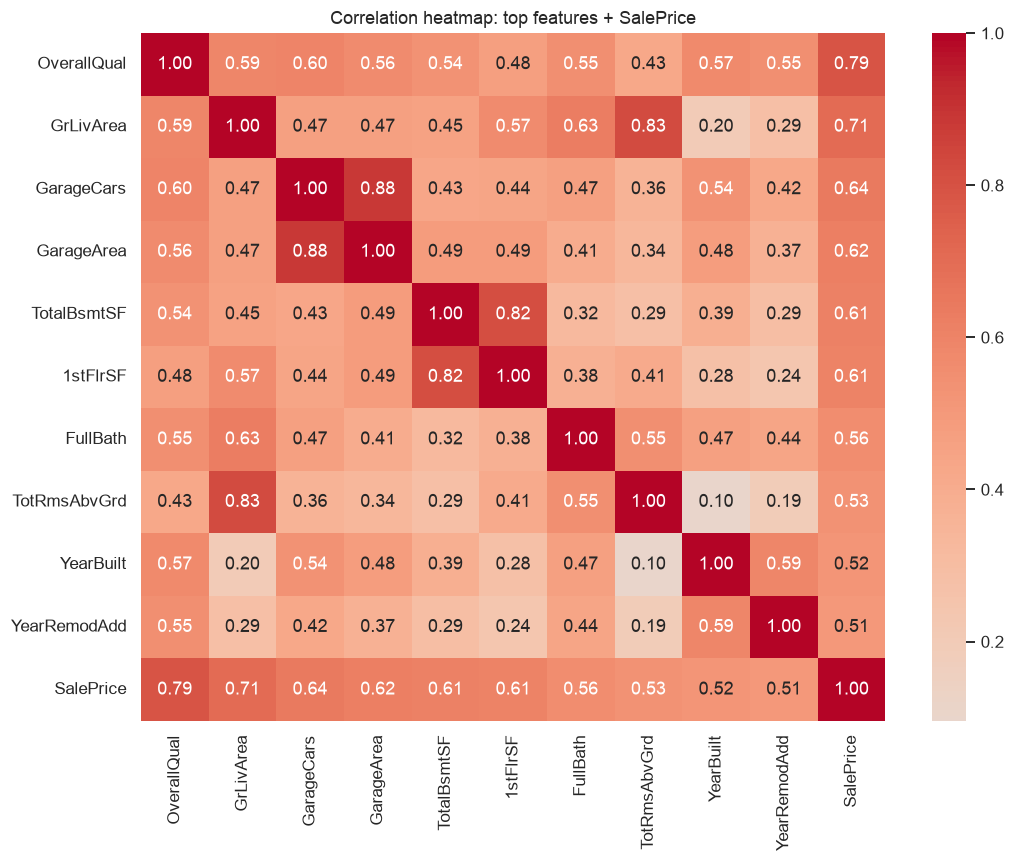

In [9]:
# Correlation heatmap among the strongest features (watch for multicollinearity).
heat_cols = list(top[:10]) + ["SalePrice"]
plt.figure(figsize=(10, 8))
sns.heatmap(train[heat_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap: top features + SalePrice")
savefig("correlation_heatmap.png")
plt.show()

**Observations**
- Strongest drivers: `OverallQual` (0.79), `GrLivArea` (0.71), `GarageCars` (0.64), `GarageArea` (0.62), `TotalBsmtSF` (0.61), `1stFlrSF` (0.61).
- Clear **multicollinearity clusters**: `GarageCars`↔`GarageArea` and `TotalBsmtSF`↔`1stFlrSF` measure nearly the same thing. This motivates the combined `TotalSF` / `TotalBaths` features in `src/features.py`.
- Quality and size dominate; year features (`YearBuilt`, `YearRemodAdd`) matter too, which the engineered `HouseAge` / `SinceRemodel` capture.

## 6. SalePrice vs key numerical features

/var/folders/hf/0h4pd6zx1vv0dwjx8bgs9r_c0000gp/T/ipykernel_60386/4263085489.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=train[col], y=train["SalePrice"], ax=ax, palette="flare")


saved /Users/mlstudio/Claude-Code/Kaggle/HousePrice-v2/reports/figures/saleprice_vs_numeric.png


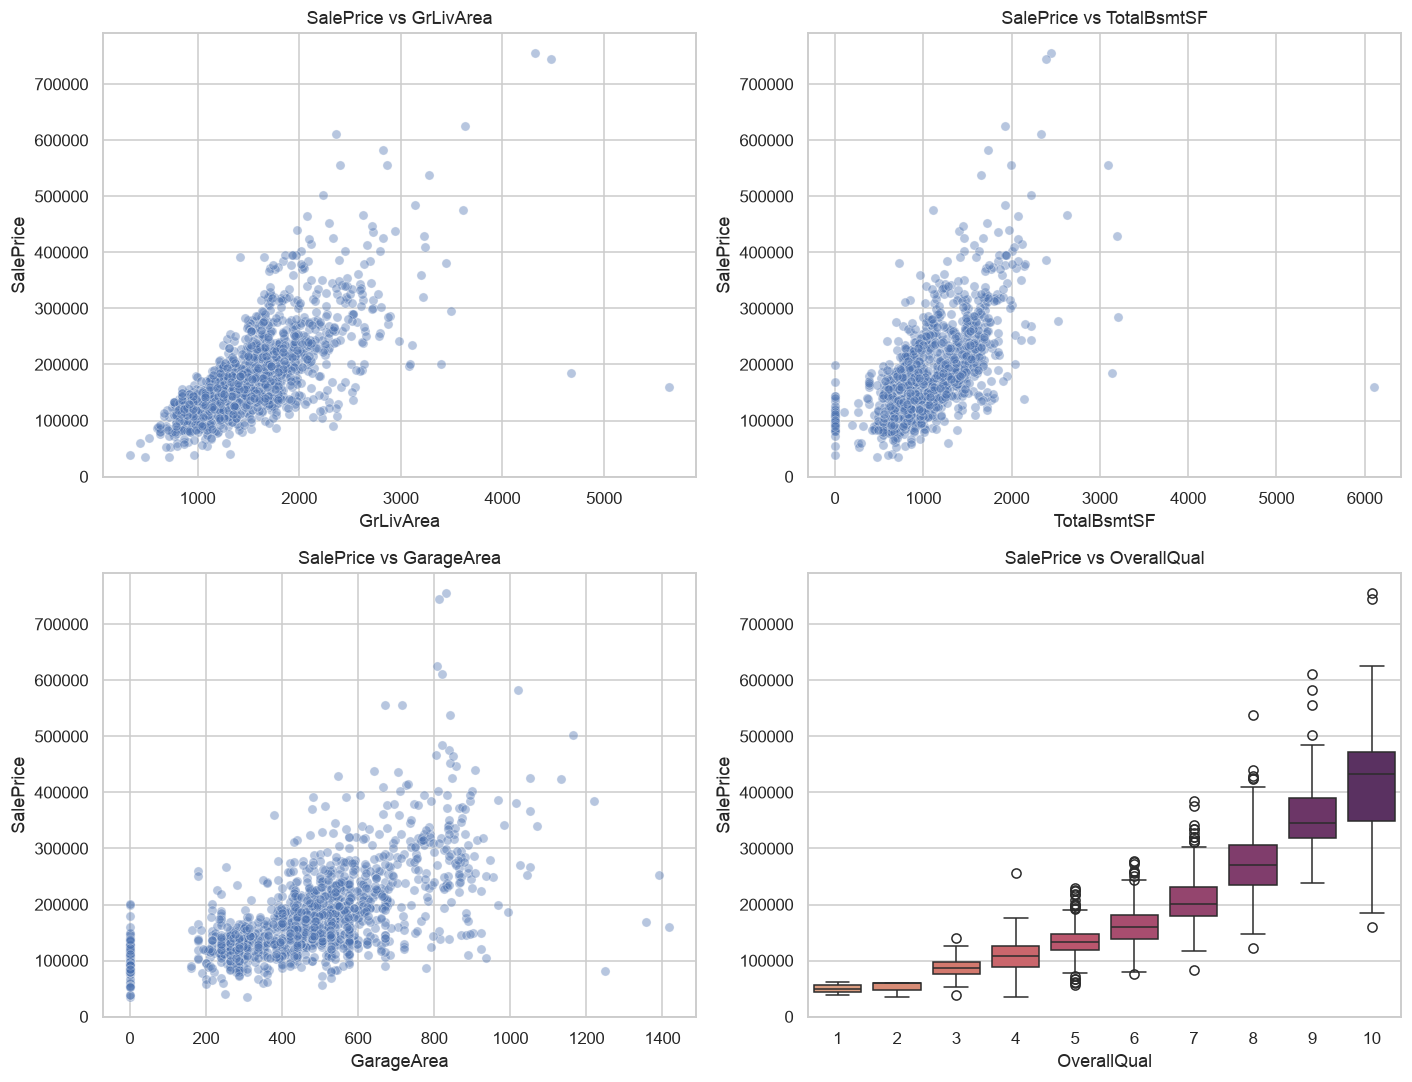

In [10]:
key_num = ["GrLivArea", "TotalBsmtSF", "GarageArea", "OverallQual"]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, col in zip(axes.ravel(), key_num):
    if col == "OverallQual":
        sns.boxplot(x=train[col], y=train["SalePrice"], ax=ax, palette="flare")
    else:
        sns.scatterplot(x=train[col], y=train["SalePrice"], ax=ax, alpha=0.4)
    ax.set_title(f"SalePrice vs {col}")
savefig("saleprice_vs_numeric.png")
plt.show()

**Observations**
- `GrLivArea` is strongly linear with price, but note the **two outliers** with very large area (>4000 sqft) yet low price — a well-known pair often dropped before training.
- `TotalBsmtSF` and `GarageArea` rise with price but have a spike at 0 (homes with no basement / no garage).
- `OverallQual` shows a clean monotonic step-up in median price per quality level — the single most predictive feature.

## 7. Categorical features vs SalePrice

/var/folders/hf/0h4pd6zx1vv0dwjx8bgs9r_c0000gp/T/ipykernel_60386/2596966187.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Neighborhood", y="SalePrice", data=train, order=order, palette="mako")


saved /Users/mlstudio/Claude-Code/Kaggle/HousePrice-v2/reports/figures/saleprice_by_neighborhood.png


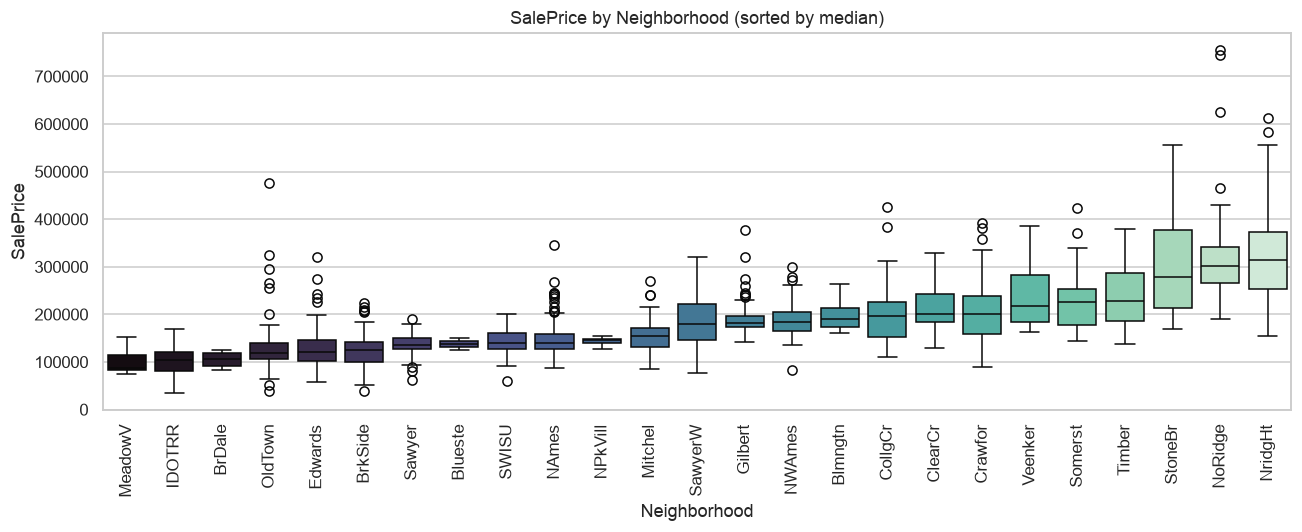

In [11]:
# Neighborhood: many levels, sort by median price for readability.
order = train.groupby("Neighborhood")["SalePrice"].median().sort_values().index
plt.figure(figsize=(12, 5))
sns.boxplot(x="Neighborhood", y="SalePrice", data=train, order=order, palette="mako")
plt.xticks(rotation=90)
plt.title("SalePrice by Neighborhood (sorted by median)")
savefig("saleprice_by_neighborhood.png")
plt.show()

/var/folders/hf/0h4pd6zx1vv0dwjx8bgs9r_c0000gp/T/ipykernel_60386/2271727118.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="SalePrice", data=train, order=order, ax=ax, palette="crest")
/var/folders/hf/0h4pd6zx1vv0dwjx8bgs9r_c0000gp/T/ipykernel_60386/2271727118.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="SalePrice", data=train, order=order, ax=ax, palette="crest")
/var/folders/hf/0h4pd6zx1vv0dwjx8bgs9r_c0000gp/T/ipykernel_60386/2271727118.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="SalePrice",

saved /Users/mlstudio/Claude-Code/Kaggle/HousePrice-v2/reports/figures/saleprice_by_categoricals.png


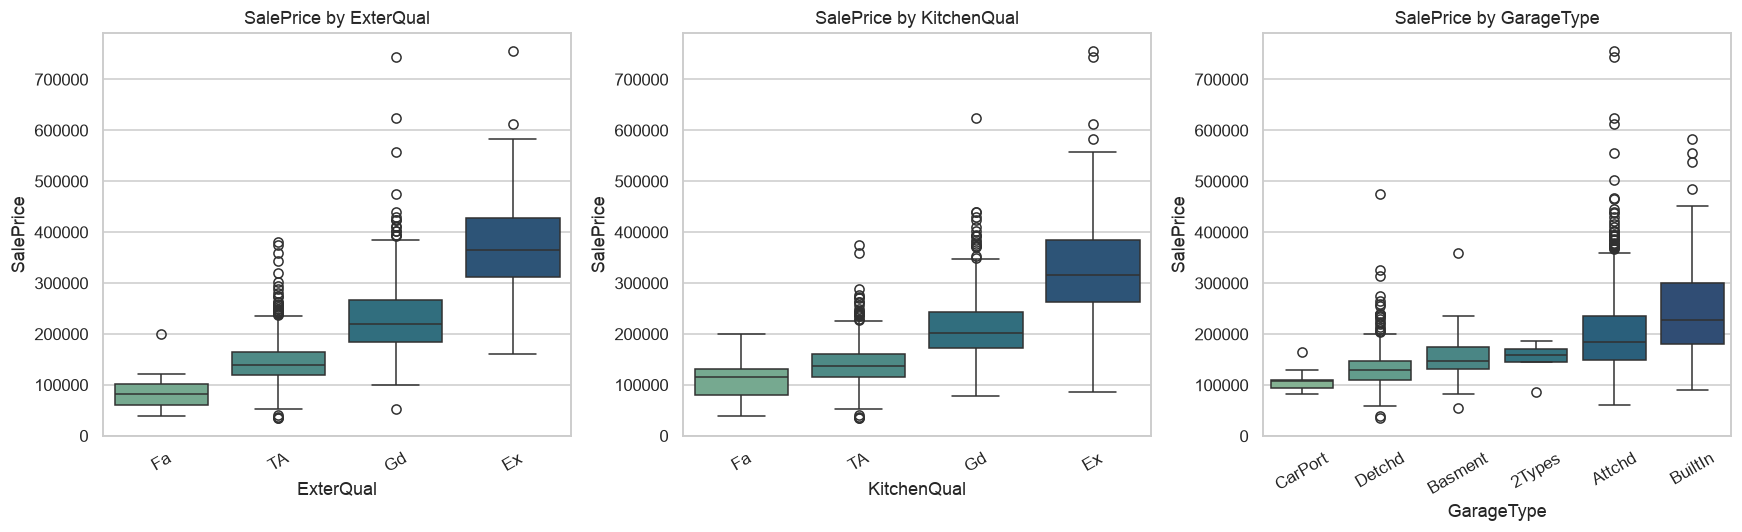

In [12]:
key_cat = ["ExterQual", "KitchenQual", "GarageType"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, key_cat):
    order = train.groupby(col)["SalePrice"].median().sort_values().index
    sns.boxplot(x=col, y="SalePrice", data=train, order=order, ax=ax, palette="crest")
    ax.set_title(f"SalePrice by {col}")
    ax.tick_params(axis="x", rotation=30)
savefig("saleprice_by_categoricals.png")
plt.show()

**Observations**
- **Neighborhood** is a huge price driver: medians range from ~$100k (MeadowV, IDOTRR) to ~$300k+ (NoRidge, NridgHt, StoneBr). Worth keeping as-is (one-hot) or target-encoding later.
- **ExterQual** and **KitchenQual** are ordinal quality grades (`Fa < TA < Gd < Ex`) with a clean monotonic price gradient — candidates for *ordinal* rather than one-hot encoding.
- **GarageType** matters: `BuiltIn`/`Attchd` homes sell higher than `Detchd`/`CarPort`; the `NA`-as-`None` (no garage) group is the cheapest.

## 8. Summary & next steps

- **Target:** model `log1p(SalePrice)` (already done in `src/train.py`).
- **Missingness:** most NAs are structural ("feature absent") — handled in `src/features.py`; only `LotFrontage` needs real imputation.
- **Top signals:** `OverallQual`, living area, garage, basement, neighborhood, exterior/kitchen quality.
- **Engineering ideas validated:** `TotalSF`, `TotalBaths`, `HouseAge`, ordinal encoding of quality grades, and dropping the two `GrLivArea` outliers.
- Saved figures live in `reports/figures/`.